# RNNs and LSTMs: Sequence Models Before Transformers

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand how an RNN processes a sequence one step at a time with a **hidden state**
- Run a **real (untrained) Elman RNN forward pass in NumPy** over a character sequence
- **Measure the vanishing-gradient problem numerically** and see how it worsens with sequence length
- Compute a single **LSTM step** by hand and see how its gates address that problem
- Know why transformers replaced RNNs for most NLP — and where full RNN/LSTM *training* arrives (**AIAT 122**)

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 06 "RNN, LSTM, and GRU for Sequential Data" — the same three cells, now unrolled by hand over characters so the vanishing gradient becomes measurable.

**Used later in:** Course 08 (AIAT 122) — Unit 3, which trains these cells properly, and Course 10 (AIAT 124) — Unit 2, which uses a character LSTM as a language model.

---


## 🌍 Why this matters: LSTMs ran Google Translate in production

The gated cell you compute by hand in Part 3 is not a historical curiosity — it was the workhorse of
deployed NLP for roughly a decade. The system that replaced Google Translate's phrase-based engine in 2016
was **a deep LSTM**: "8 encoder and 8 decoder layers using attention and residual connections", reported to
cut translation errors by an average of **60%** against the previous production system
(Wu et al., [arXiv:1609.08144](https://arxiv.org/abs/1609.08144)). The same architecture was published for
large-scale speech recognition in the same period (Sak, Senior & Beaufays, *Long Short-Term Memory
Recurrent Neural Network Architectures for Large Scale Acoustic Modeling*, Interspeech 2014). The little
box of gates below shipped to hundreds of millions of people.

**What goes wrong without this lesson.** A feed-forward network takes a fixed-size input and has no memory:
give it *"the **animal** ... was **tired**"* and it has no mechanism at all for connecting those two words.
The RNN loop is the smallest possible fix — one hidden vector, rewritten at every step.

Then you will **measure** why the smallest fix is not enough: the gradient signal that should teach the
network to link far-apart words dies exponentially with distance. The LSTM's three gates exist because of
that measurement, not because of a hunch. Most courses assert the vanishing gradient; this one makes you
compute it.

## 📥 Inputs & 📤 Outputs

**Inputs:** the character sequence `"hello world"` and small random (seeded, untrained) weight matrices — no downloads, no training.

**Outputs:** a step-by-step hidden-state trace, a measured gradient-norm curve showing the vanishing-gradient problem, and one hand-computed LSTM step.

---


## Part 1: The RNN Idea — a Loop with Memory

A feed-forward network (Course 01) maps one fixed-size input to one output. Text is a **sequence**: each
word/character depends on what came before. A **Recurrent Neural Network (RNN)** handles this with a loop:

```
h_t = tanh( W_xh · x_t  +  W_hh · h_(t-1)  +  b )
```

- `x_t` — the input at step *t* (here: a one-hot vector for the current character)
- `h_t` — the **hidden state**: a vector that carries a summary of everything read so far
- `W_xh`, `W_hh` — the input and recurrent weight matrices (the same weights are reused at every step)

Below we run this equation **for real** on `"hello world"`. The weights are random and untrained, so the
network's "predictions" are meaningless — the point is to watch the mechanism: one shared set of weights,
applied step by step, with the hidden state as memory.


In [1]:
# Build a real Elman RNN in NumPy and feed it "hello world" one character at a time.
# The key idea: ONE hidden-state vector is rewritten at every step — that vector
# is the network's entire memory of everything it has read so far.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
np.set_printoptions(precision=2, suppress=True)

# --- Encode the text as one-hot vectors -------------------------------------
text = "hello world"
vocab = sorted(set(text))
char_to_int = {ch: i for i, ch in enumerate(vocab)}
V = len(vocab)                       # vocabulary size
print(f"Text: {text!r}")
print(f"Vocabulary ({V} chars): {vocab}")

def one_hot(ch):
    v = np.zeros(V)
    v[char_to_int[ch]] = 1.0
    return v

# --- Define a real Elman RNN (untrained: random seeded weights) -------------
H = 8                                # hidden-state size
W_xh = rng.normal(0, 0.5, (H, V))    # input  -> hidden
W_hh = rng.normal(0, 0.5, (H, H))    # hidden -> hidden (the recurrence)
b_h  = np.zeros(H)
W_hy = rng.normal(0, 0.5, (V, H))    # hidden -> output (next-char scores)

def softmax(z):
    e = np.exp(z - z.max())
    return e / e.sum()

# --- Forward pass, one character at a time ----------------------------------
print(f"\nRNN forward pass (hidden size {H}, weights random & untrained):")
print(f"{'step':>4s} {'char':>5s}   {'|h_t|':>6s}   first 4 hidden values")
print("-" * 60)
h = np.zeros(H)
for t, ch in enumerate(text):
    h = np.tanh(W_xh @ one_hot(ch) + W_hh @ h + b_h)
    print(f"{t:4d} {ch!r:>5s}   {np.linalg.norm(h):6.2f}   {h[:4]}")

# The output layer turns the final hidden state into next-char probabilities
probs = softmax(W_hy @ h)
pred = vocab[int(np.argmax(probs))]
print(f"\nAfter reading the whole text, the output layer 'predicts' the next char: {pred!r}")
print("(Random weights -> a meaningless prediction. TRAINING would adjust all four")
print(" weight matrices so these predictions match real text. That's AIAT 122 material.)")

Text: 'hello world'
Vocabulary (8 chars): [' ', 'd', 'e', 'h', 'l', 'o', 'r', 'w']

RNN forward pass (hidden size 8, weights random & untrained):
step  char    |h_t|   first 4 hidden values
------------------------------------------------------------
   0   'h'     0.99   [ 0.05  0.02  0.48 -0.43]
   1   'e'     1.11   [-0.06  0.21 -0.01 -0.83]
   2   'l'     1.68   [-0.81 -0.63  0.19 -0.72]
   3   'l'     1.55   [ 0.28 -0.82  0.12 -0.66]
   4   'o'     1.39   [ 0.55  0.03  0.76 -0.81]
   5   ' '     1.76   [ 0.13  0.49 -0.42 -0.67]
   6   'w'     1.47   [ 0.77 -0.21  0.59  0.47]
   7   'o'     1.83   [0.91 0.52 0.43 0.09]
   8   'r'     1.88   [ 0.84 -0.68 -0.53 -0.37]
   9   'l'     1.90   [-0.88  0.34  0.79 -0.87]
  10   'd'     1.70   [-0.71  0.68  0.26 -0.32]

After reading the whole text, the output layer 'predicts' the next char: 'r'
(Random weights -> a meaningless prediction. TRAINING would adjust all four
 weight matrices so these predictions match real text. That's AIAT 122 

Two things to notice in the trace above:

- The hidden state changes at **every** step — it is a running summary of the sequence so far.
- The **same** weight matrices processed all 11 characters. An RNN's size does not grow with sequence length.

## Part 2: The Vanishing Gradient — Measured, Not Just Asserted

Training an RNN means sending gradient signals **backwards through the loop**. The gradient that connects
step *t* to step *t−k* is a **product of k Jacobian matrices**, one per step. With `tanh` activations and
typical weights, each factor tends to shrink the signal — so the product shrinks **exponentially** in `k`.

Consequence: the network barely learns connections between far-apart words ("The **animal** ... was
**tired**"). This is the **vanishing gradient problem**, and it is why plain RNNs struggle with long text.

We can measure it. Below we run a 50-step RNN forward pass and multiply the actual Jacobians
`∂h_t/∂h_(t−1) = diag(1 − h_t²) · W_hh` step by step, tracking how much gradient signal survives.


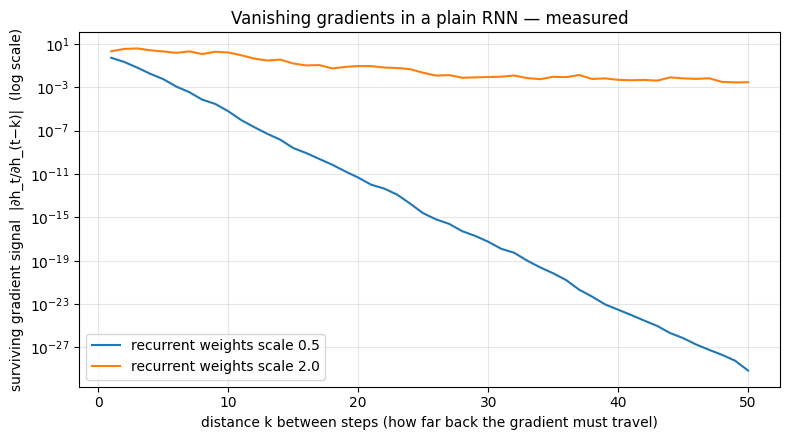

Surviving gradient signal (spectral norm of the Jacobian product):
distance k    scale 0.5    scale 2.0
         1     5.25e-01     2.10e+00
        10     6.19e-06     1.63e+00
        25     2.41e-15     2.16e-02
        50     7.33e-30     2.92e-03

Read the table: with typical (scale 0.5) weights, the gradient signal from
50 steps back is 7e-30 — effectively zero. Larger recurrent
weights (scale 2.0) decay more slowly here, but the signal still fades
(3e-03 at k=50 and falling). Either way, the network struggles
to learn long-range connections. (With even larger weights, gradients can
instead EXPLODE — the mirror problem, usually handled by gradient clipping.)


In [2]:
# Measure the vanishing-gradient problem instead of just asserting it.
# We multiply step-to-step Jacobians along a 50-step RNN and track how much
# gradient signal survives — this product is exactly what backprop-through-time uses.

T = 50                                # sequence length
X_DIM = 4

def gradient_survival(weight_scale, seed=42):
    """Forward-pass a random T-step RNN; return |product of Jacobians| after each step."""
    g = np.random.default_rng(seed)
    W_hh = g.normal(0, weight_scale / np.sqrt(H), (H, H))
    W_xh = g.normal(0, 0.5, (H, X_DIM))
    h = np.zeros(H)
    J = np.eye(H)
    norms = []
    for t in range(T):
        x = g.normal(0, 1, X_DIM)
        h = np.tanh(W_xh @ x + W_hh @ h)
        J = (np.diag(1 - h**2) @ W_hh) @ J     # chain one more step into the product
        norms.append(np.linalg.norm(J, 2))
    return np.array(norms)

# Two settings: typical initialization (0.5) vs deliberately large recurrent weights (2.0).
norms_small = gradient_survival(weight_scale=0.5)
norms_large = gradient_survival(weight_scale=2.0)

# Log-scale plot: a straight falling line here means exponential vanishing.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(range(1, T + 1), norms_small, label="recurrent weights scale 0.5")
ax.semilogy(range(1, T + 1), norms_large, label="recurrent weights scale 2.0")
ax.set_xlabel("distance k between steps (how far back the gradient must travel)")
ax.set_ylabel("surviving gradient signal  |∂h_t/∂h_(t−k)|  (log scale)")
ax.set_title("Vanishing gradients in a plain RNN — measured")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Surviving gradient signal (spectral norm of the Jacobian product):")
print(f"{'distance k':>10s} {'scale 0.5':>12s} {'scale 2.0':>12s}")
for k in [1, 10, 25, 50]:
    print(f"{k:>10d} {norms_small[k-1]:>12.2e} {norms_large[k-1]:>12.2e}")

print(f"\nRead the table: with typical (scale 0.5) weights, the gradient signal from")
print(f"{T} steps back is {norms_small[-1]:.0e} — effectively zero. Larger recurrent")
print(f"weights (scale 2.0) decay more slowly here, but the signal still fades")
print(f"({norms_large[-1]:.0e} at k={T} and falling). Either way, the network struggles")
print("to learn long-range connections. (With even larger weights, gradients can")
print("instead EXPLODE — the mirror problem, usually handled by gradient clipping.)")

## 💬 Discuss

You just measured something most textbooks only assert. Argue about what the measurement licenses.

1. At 50 steps back, the surviving gradient signal with typical weights was about **7×10⁻³⁰**. The
   larger-weight setting decayed far more slowly but was still falling (about 3×10⁻³ at k=50). Does "the
   gradient is tiny" *prove* "the network cannot learn the dependency", or only "it cannot learn it *this
   way*"? Design the experiment that separates those two claims.
2. The untrained forget gate kept **58%** of the old memory on average — but the weights are random, so
   that number says nothing about language. What exactly would you have to train and measure before you
   could claim "this LSTM remembers the subject of the sentence"? Name the dataset and the metric.
3. Transformers replaced RNNs largely because RNNs cannot be parallelized across time. But suppose your
   deployment target is an offline Arabic voice-command device with 512 MB of RAM and a hard 50 ms latency
   budget. Which would you ship, and what single measurement would change your mind?

## Part 3: LSTMs — Gates That Protect the Memory

The **Long Short-Term Memory (LSTM)** network (1997) redesigns the recurrence to fight this decay. It adds a
**cell state** `c_t` — a memory conveyor belt — and three learned **gates** (sigmoid outputs between 0 and 1)
that control it:

| Gate | Question it answers | Equation role |
|------|--------------------|----------------|
| **Forget** gate `f` | How much of the old memory do we keep? | `c_t = f ⊙ c_(t−1) + …` |
| **Input** gate `i` | How much of the new candidate do we write? | `… + i ⊙ c̃_t` |
| **Output** gate `o` | How much of the memory do we reveal? | `h_t = o ⊙ tanh(c_t)` |

The key is the cell-state update `c_t = f ⊙ c_(t−1) + i ⊙ c̃_t`: it is **additive**. When the forget gate is
near 1, memory (and gradient) can flow across many steps almost untouched, instead of being squeezed through
a `tanh`-and-matrix product at every step. That is how LSTMs keep long-range information alive far better
than plain RNNs.

Let's compute **one LSTM step** by hand to make the gates concrete.


In [3]:
# Why LSTMs survived where plain RNNs failed: gates plus an additive memory lane.
# Below, every gate of one LSTM step is computed by hand so you can see what
# each one contributes to the new cell state.

# One LSTM step, computed by hand (random seeded weights, untrained)
g2 = np.random.default_rng(7)
D = 4                                  # input size for this demo

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# One weight matrix per gate (each sees [input, previous hidden] concatenated)
W_f, W_i, W_o, W_c = (g2.normal(0, 0.5, (H, D + H)) for _ in range(4))

x_t    = g2.normal(0, 1, D)            # current input
h_prev = g2.normal(0, 0.5, H)          # previous hidden state
c_prev = g2.normal(0, 0.5, H)          # previous cell state (the memory belt)
z = np.concatenate([x_t, h_prev])

f = sigmoid(W_f @ z)                   # forget gate: keep how much old memory?
i = sigmoid(W_i @ z)                   # input gate: write how much new info?
o = sigmoid(W_o @ z)                   # output gate: reveal how much?
c_tilde = np.tanh(W_c @ z)             # candidate new memory

c_t = f * c_prev + i * c_tilde         # ADDITIVE memory update
h_t = o * np.tanh(c_t)                 # what the rest of the network sees

print("One LSTM step (all values computed above):")
print(f"  forget gate f    = {f}")
print(f"  input  gate i    = {i}")
print(f"  output gate o    = {o}")
print(f"  old cell  c_prev = {c_prev}")
print(f"  new cell  c_t    = {c_t}")
print(f"  new hidden h_t   = {h_t}")

kept = float(np.mean(f))
print(f"\nOn average this (untrained) forget gate kept {kept:.0%} of the old memory.")
print("Training would teach the gates WHEN to keep, write, and reveal — e.g. keep")
print("'animal' in memory until 'tired' arrives. Full LSTM training: AIAT 122.")

One LSTM step (all values computed above):
  forget gate f    = [0.63 0.48 0.45 0.64 0.81 0.71 0.6  0.3 ]
  input  gate i    = [0.34 0.6  0.55 0.39 0.51 0.4  0.37 0.37]
  output gate o    = [0.67 0.95 0.4  0.28 0.62 0.57 0.1  0.18]
  old cell  c_prev = [ 0.11  0.5  -0.87 -0.39  0.09  0.2  -0.19  0.51]
  new cell  c_t    = [-0.25  0.79 -0.56 -0.22  0.44  0.08  0.19  0.14]
  new hidden h_t   = [-0.17  0.63 -0.2  -0.06  0.26  0.04  0.02  0.03]

On average this (untrained) forget gate kept 58% of the old memory.
Training would teach the gates WHEN to keep, write, and reveal — e.g. keep
'animal' in memory until 'tired' arrives. Full LSTM training: AIAT 122.


## Part 4: RNNs/LSTMs in NLP — and Why Transformers Took Over

Before transformers (2017), RNNs/LSTMs powered most sequence NLP:

- **Text generation** — predict the next word/character (the output layer you saw in Part 1)
- **Sentiment classification** — read the sequence, classify from the final hidden state
- **Machine translation** — two RNNs: an encoder and a decoder (next notebooks!)
- **Named entity recognition** — one label per step

Their two structural weaknesses are exactly what you measured and computed today:

1. **Long-range connections decay** (Part 2) — even LSTMs only soften the problem.
2. **No parallelism** — step *t* needs `h_(t−1)`, so a 1,000-word text takes 1,000 sequential steps;
   attention (previous notebook) connects any two words **directly** and computes all positions **at once**.

That is why the rest of this unit — BERT (`03`), attention-based translation (`04`), GPT (`05`) — is built
on attention instead.

---

## ✅ Summary

**What you actually did here** (all computed live, nothing trained):

- Ran a real Elman RNN forward pass in NumPy: `h_t = tanh(W_xh·x_t + W_hh·h_(t−1) + b)` over `"hello world"`
- Measured the vanishing-gradient problem: with typical weight scales, the surviving gradient signal from 50 steps back collapses to roughly 10⁻³⁰ (exact values are in the table you computed)
- Computed one LSTM step by hand and saw how the additive, gated cell state protects memory

**What is deliberately NOT here:** training. Building and training real RNN/LSTM models in Keras/PyTorch —
losses, backpropagation through time, gradient clipping — is **AIAT 122 (Course 08, Deep Learning)** material.

**Next:** `03_bert_advanced_usage.ipynb` — use a pretrained transformer for sentiment classification.


## ⚠️ Where this breaks

**What you measured is a real limit, not a solved one.** LSTMs *soften* the vanishing gradient; they do not
remove it. Past a few hundred steps even a well-trained LSTM loses the thread, which is why long-document
tasks migrated to attention.

**The structural limit is speed, and no amount of training fixes it.** Step *t* needs `h_(t−1)`, so a
1,000-token document is 1,000 sequential steps; a transformer computes all 1,000 positions at once. On
modern hardware that is the difference between an afternoon and a week.

**The mirror failure:** with larger recurrent weights the same Jacobian product *explodes* instead of
vanishing — that is the direction the scale-2.0 curve was heading before the tanh saturated it. Production
RNN training always includes gradient clipping for this reason, and neither failure shows up in a loss
curve until it has already ruined the run.

**The honest scope of this notebook:** every weight here is random and untrained, so every hidden state,
gate value and next-character prediction is meaningless *as language*. Only the mechanism and the gradient
measurement are real. Training these cells belongs to AIAT 122.

**When an RNN or LSTM is still the right choice — and it sometimes is:**
- Short sequences, small data, CPU-only inference, tight latency: an LSTM has a fraction of a transformer's
  parameters and never builds an `n × n` attention matrix.
- True streaming, where tokens arrive one at a time indefinitely and there is no "whole sequence" to attend
  over.
- Modern linear-time sequence models (Mamba, [arXiv:2312.00752](https://arxiv.org/abs/2312.00752)) revive
  exactly this recurrent-state idea in a form that trains in parallel. Recurrence is not obsolete; the 1990s
  *implementation* of it is.

## 📚 References

The recurrent-network lineage, from the seminal papers to modern recurrence and the cost that revived it:

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science, 14(2), 179-211.
2. Bengio, Y., Simard, P., & Frasconi, P. (1994). *Learning Long-Term Dependencies with Gradient Descent is Difficult*. IEEE Transactions on Neural Networks, 5(2).
3. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735-1780.
4. Cho, K., van Merrienboer, B., Gulcehre, C., et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation*. EMNLP 2014. [arXiv:1406.1078](https://arxiv.org/abs/1406.1078)
5. Gu, A., & Dao, T. (2023). *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*. [arXiv:2312.00752](https://arxiv.org/abs/2312.00752)
6. Dao, T., & Gu, A. (2024). *Transformers are SSMs: Generalized Models and Efficient Algorithms Through Structured State Space Duality*. ICML 2024. [arXiv:2405.21060](https://arxiv.org/abs/2405.21060) — Mamba-2; recurrence and attention shown to be two views of the same structured matrices.
7. Jiang, J., Yang, P., Zhang, R., & Liu, F. (2026). *Towards Efficient Large Language Model Serving: A Survey on System-Aware KV Cache Optimization*. [arXiv:2607.08057](https://arxiv.org/abs/2607.08057) — the memory a transformer pays per token of history, and that an RNN's fixed-size state does not.
